In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import igraph
import seaborn
###import packages
from scEasyMode import mousefilter
from scEasyMode import clusterplot
from scEasyMode import pymulti
from scEasyMode import sceasy

### define files needed for multiseq processing

In [2]:
####define files
R1 = '../multi_raw/L0027_R1.fastq.gz'
R2 = '../multi_raw/L0027_R2.fastq.gz'
####define metadata
v10x = 'v3.1'
expname = 'BGday6_'
sampname = 'BGday6_'
####define length of sequences
len_10x = 16
len_umi = 12
len_multi = 8
####define multiseq barcodes file
bcfile = '../multi_raw/LMOlist_L0027.csv'
bcsmulti = pd.read_csv(bcfile,sep=',',index_col=1,header=None)
bcsmulti.columns = ['multi']
bcsmulti = bcsmulti['multi'].tolist()
####define 10x barcodes whitelist
bc10xfile = '../multi_raw/barcodes.tsv'
bcs10x = pd.read_csv(bc10xfile,sep='\t',header=None)
bcs10x['10x'] = bcs10x.apply(lambda row: row[0][:-2],axis=1)
bcs10x = bcs10x['10x'].tolist()

### run multiseq processing

#### 1. it splits the data from fastqs to a readtable
#### 2. it stacks the reads by cells and then calculate the percentile representation of each barcode
#### 3. it implements a correction that you choose (median, percentile only, or log2(zscore)
#### 4. it returns plots and a table of calls for each cell

Multiseq rate is:  85.10412205688921
10X Cell Barcode rate is:  20.37448208869417
Duplication rate is:  5.69871421136442


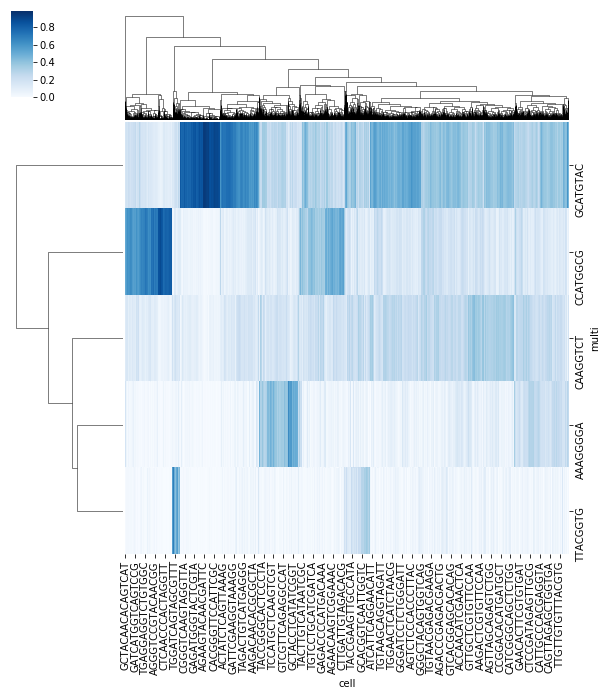

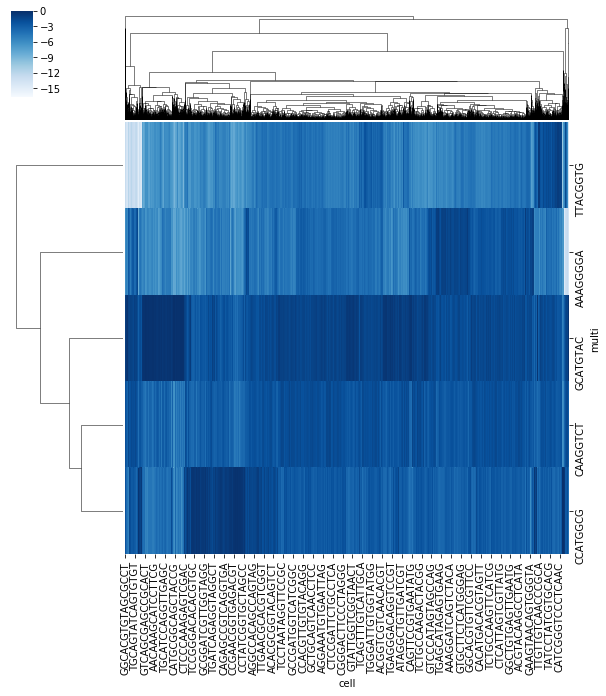

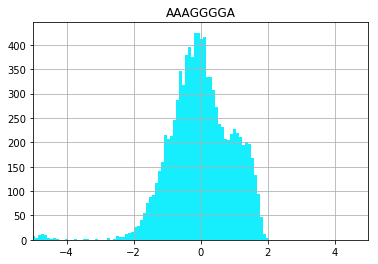

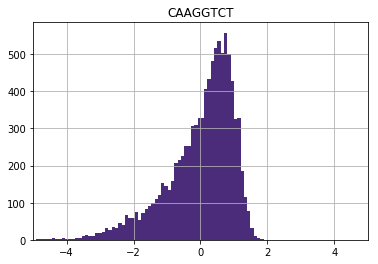

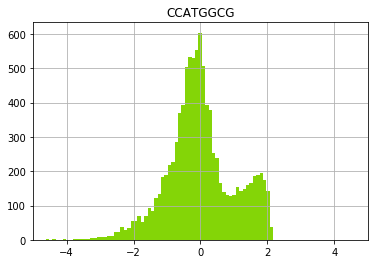

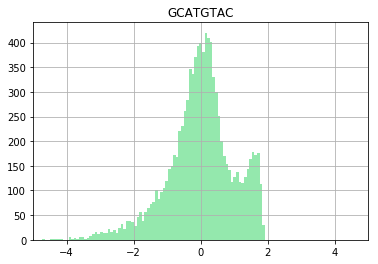

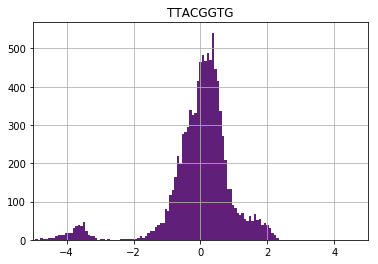

In [3]:
pymulti.pymulti(R1,R2,bcsmulti,bcs10x,split=True)

### split out mouse cells and human cells from data

#### you can split the human cells from the mouse cells from each other after doing an alignment to both A) mm10hg19 B) hg19


Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Trying to set attribute `.obs` of view, making a copy.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


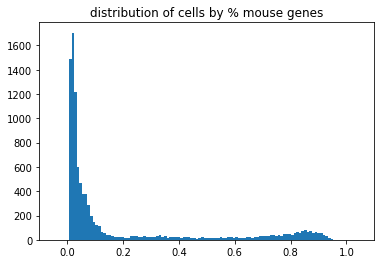

Trying to set attribute `.var` of view, making a copy.
... storing 'feature_types' as categorical
Trying to set attribute `.var` of view, making a copy.
... storing 'genome' as categorical
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Trying to set attribute `.var` of view, making a copy.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
... storing 'feature_types' as categorical
Trying to set attribute `.var` of view, making a copy.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
... storing 'genome' as categorical


(1606, 54232)
(6888, 33538)


In [4]:
file1 = 'filtered_feature_bc_mm10hg19_matrix.h5'
file2 = 'filtered_feature_bc_hg38_matrix.h5'
mouse,human = mousefilter.main(file1,file2)
print(mouse.shape)
print(human.shape)

# overlay metadata

#### this takes the multiseq/hashing calls from before and overlays it on top of the 10x gene expression matrix.
#### the qc function also provides the standard pre-clustering qc metrics for you to then filter cells/genes

Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Trying to set attribute `.obs` of view, making a copy.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
... storing 'call' as categorical
... storing 'sample' as categorical


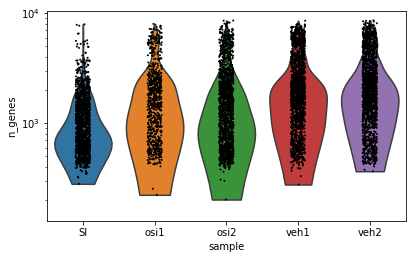

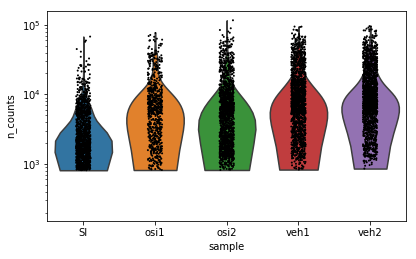

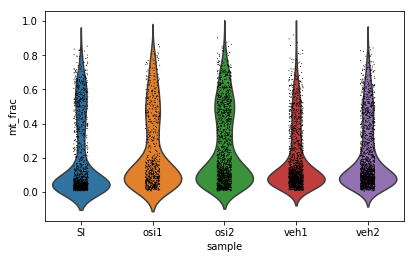

plotting mt_frac below.


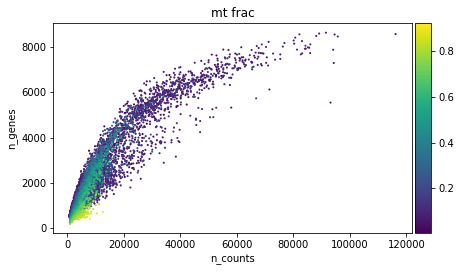

Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


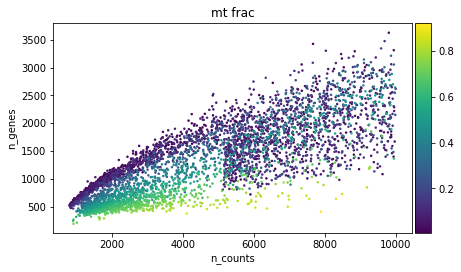

Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


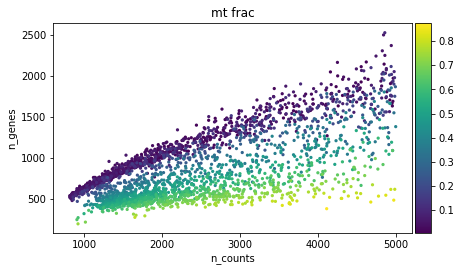

Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


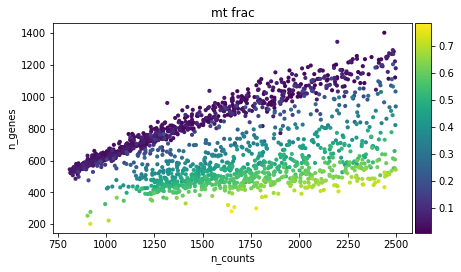

plotting sample below.


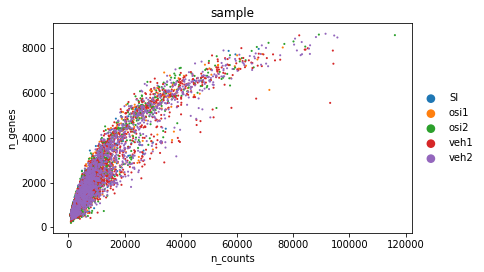

Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


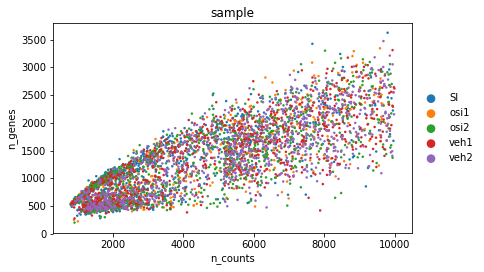

Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


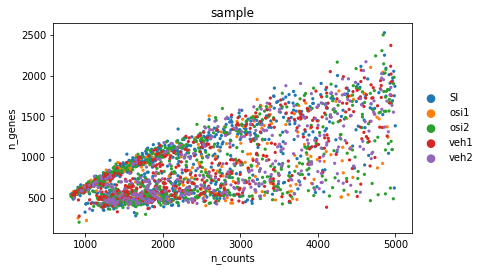

Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


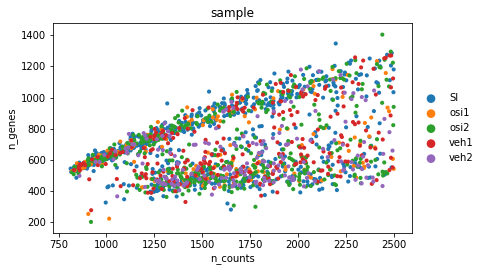

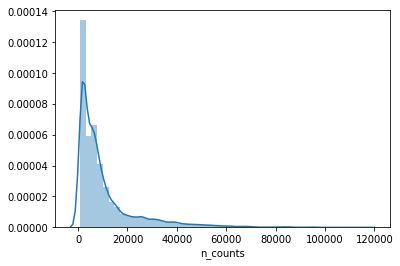

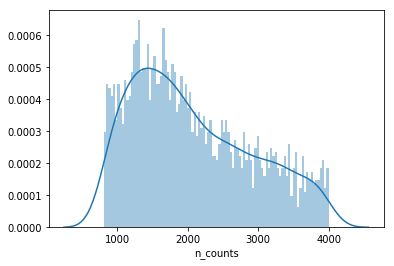

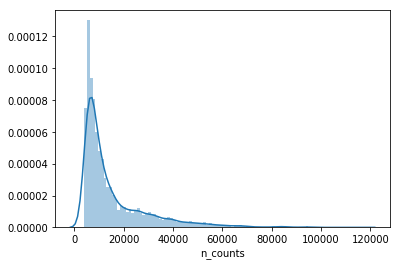

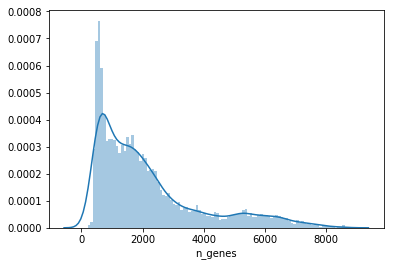

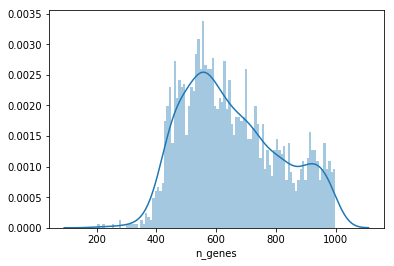

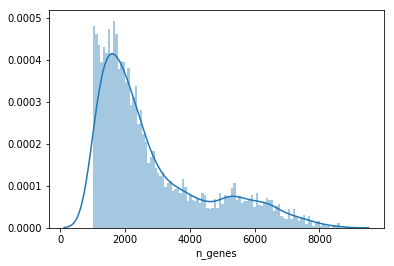

<Figure size 432x288 with 0 Axes>

In [5]:
###read in data by species
human = sceasy.read_species(human=True)
###overlay metadata
human = sceasy.overlay_meta(human,bcfile)
###qc
human = sceasy.qc_all(human)

# Filtering

#### Filtering can be done in one step with this combined filters function

Trying to set attribute `.obs` of view, making a copy.


Total number of cells: 5854
Number of cells after min count filter: 5854


Trying to set attribute `.obs` of view, making a copy.


Number of cells after max count filter: 5854
Number of cells after MT filter: 4107
Number of cells after gene filter: 4107
Total number of genes: 33538
Number of genes after cell filter: 14888
Total number of genes: 33538
Number of genes after cell filter: 14556

 Number of highly variable genes: 2999


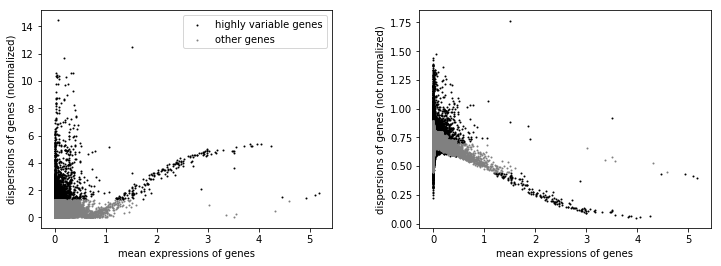


 Number of highly variable genes: 2999


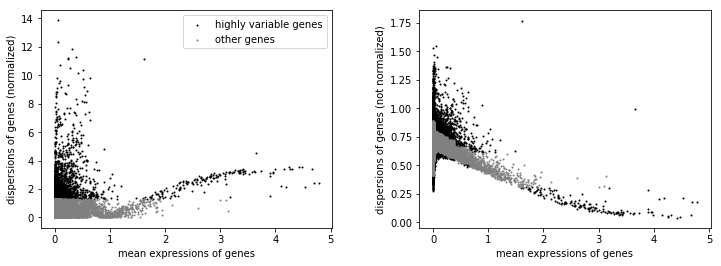

(5854, 14888)
(4107, 14556)


In [6]:
###filtering by cells by parameters
##define
mt_thresh = 0.8
min_cells = 20
sig_pct = 15
##filter
human,clean = sceasy.filters(human,mt_thresh=mt_thresh,min_cells=min_cells,max_counts=max_counts,sig_pct=sig_pct)

# visualize
#### this calculates and plots the visualizations across pca, umap, diffusion map, and force directed graph space at once
#### also plots the distribution of different variables across these visualizations

... storing 'phase' as categorical


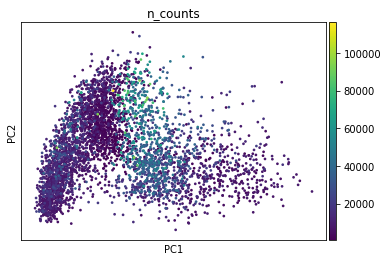

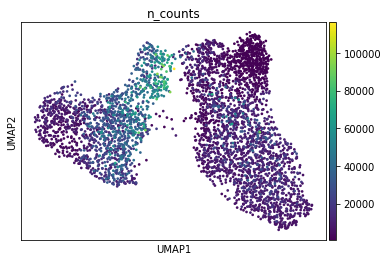

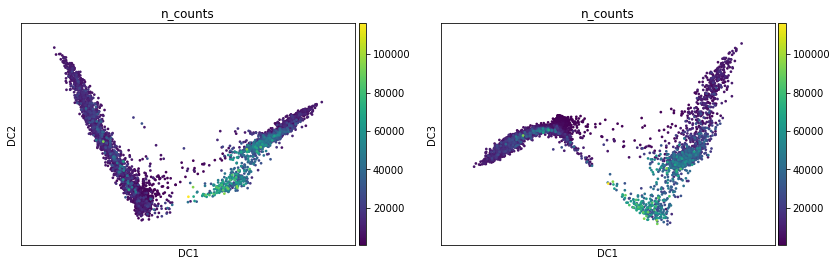

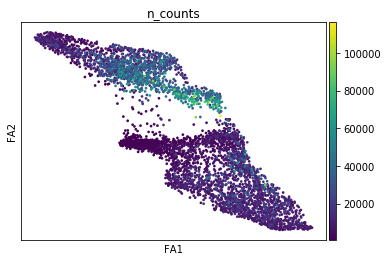

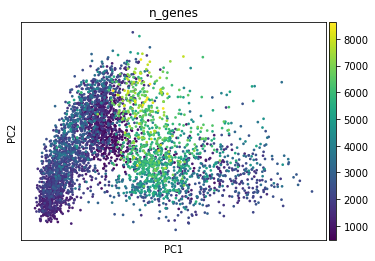

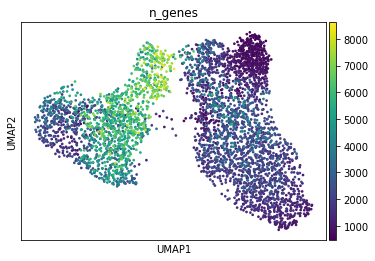

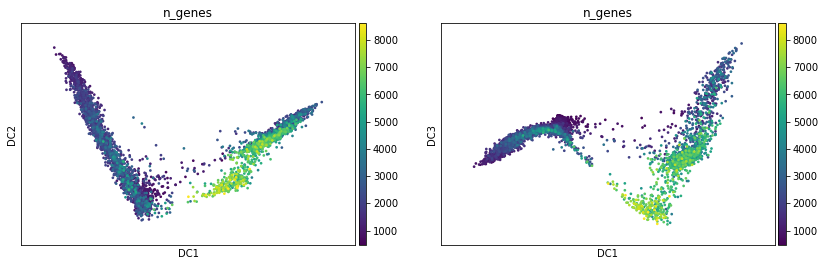

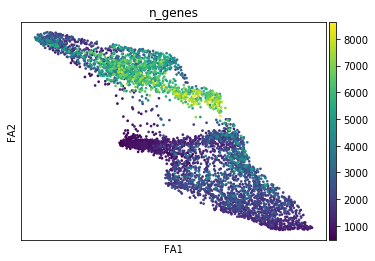

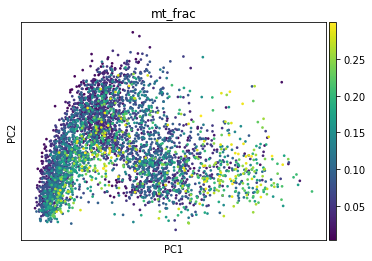

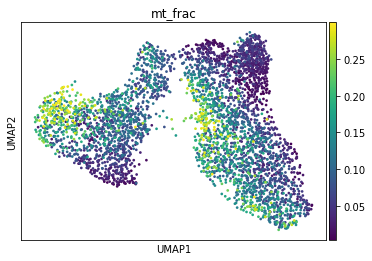

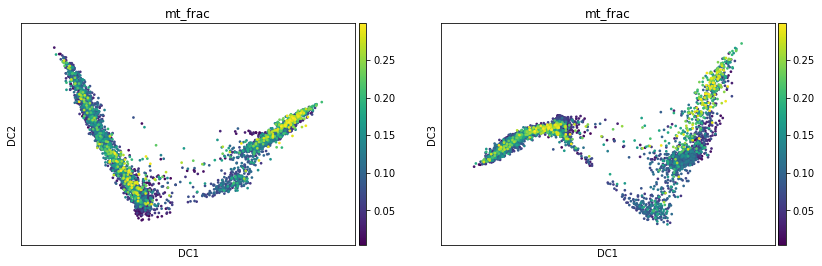

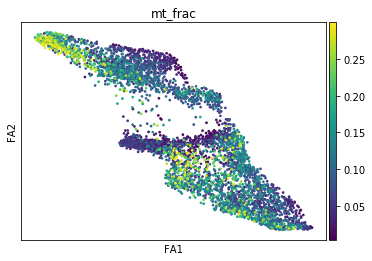

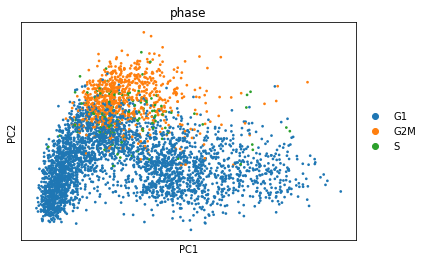

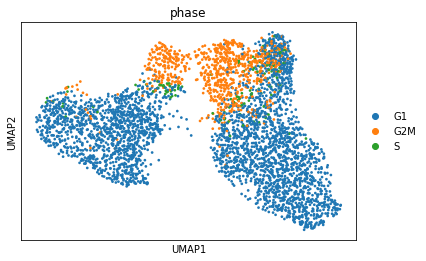

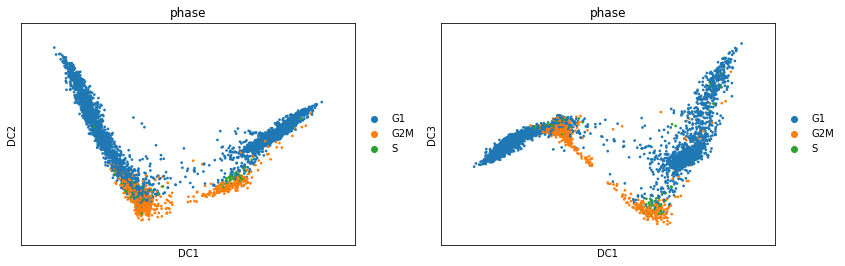

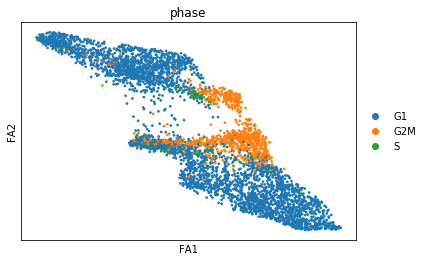

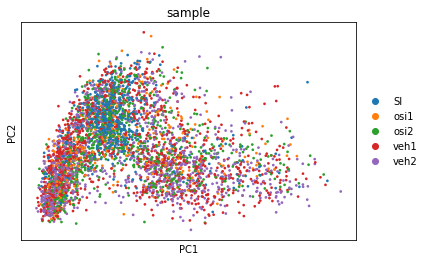

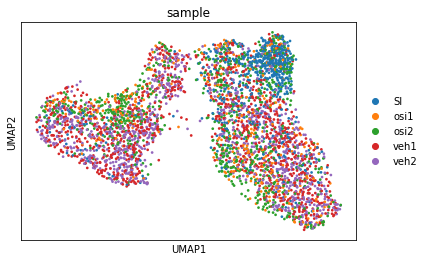

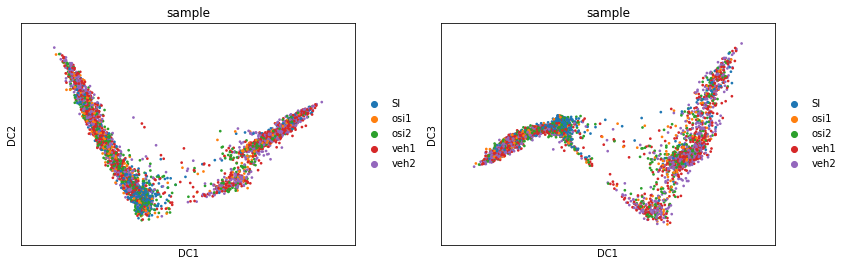

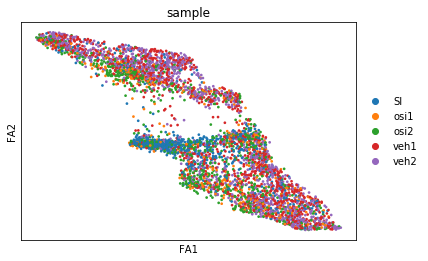

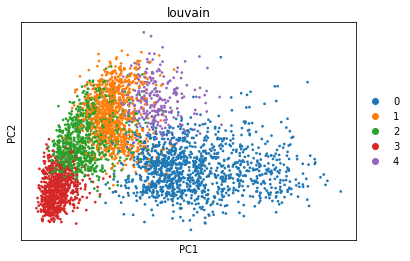

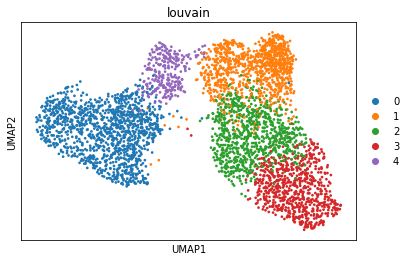

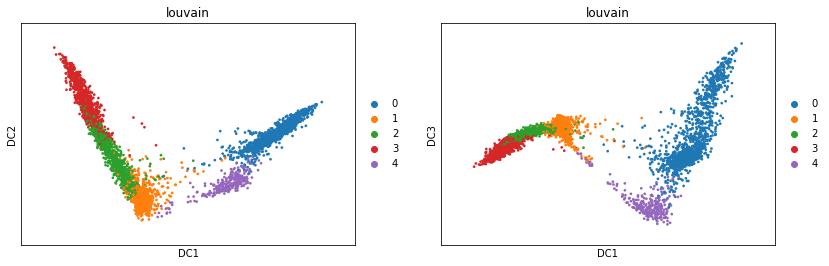

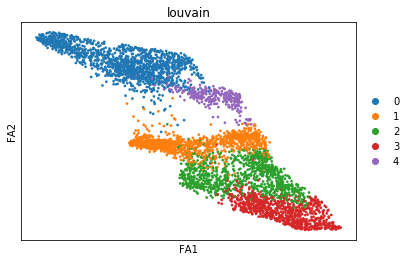

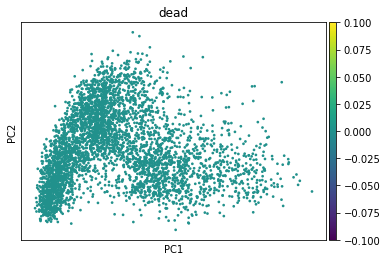

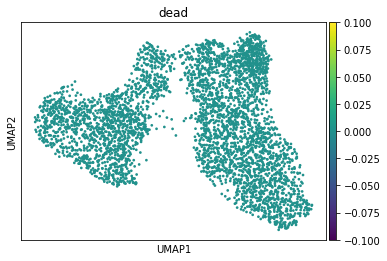

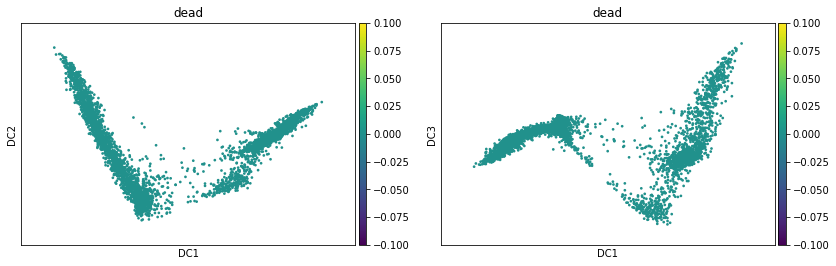

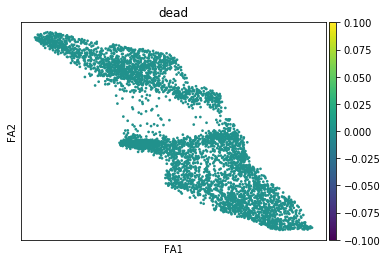

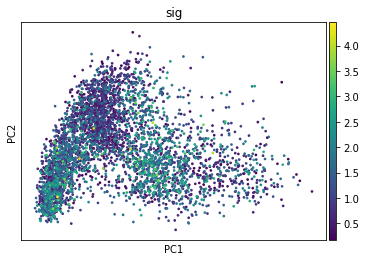

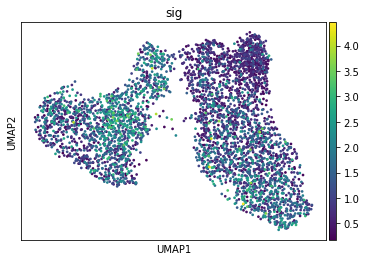

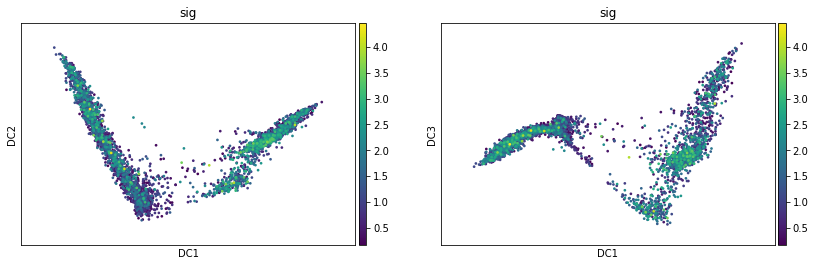

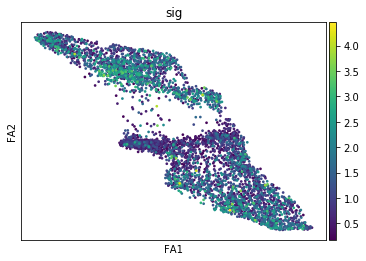

In [7]:
##visualize
clean = sceasy.visualize(clean)

# stack clusters by covariates
#### you can visualize a percentile change of a grouping in a different variable. 
#### here is shown the distribution of samples across cell cycle states

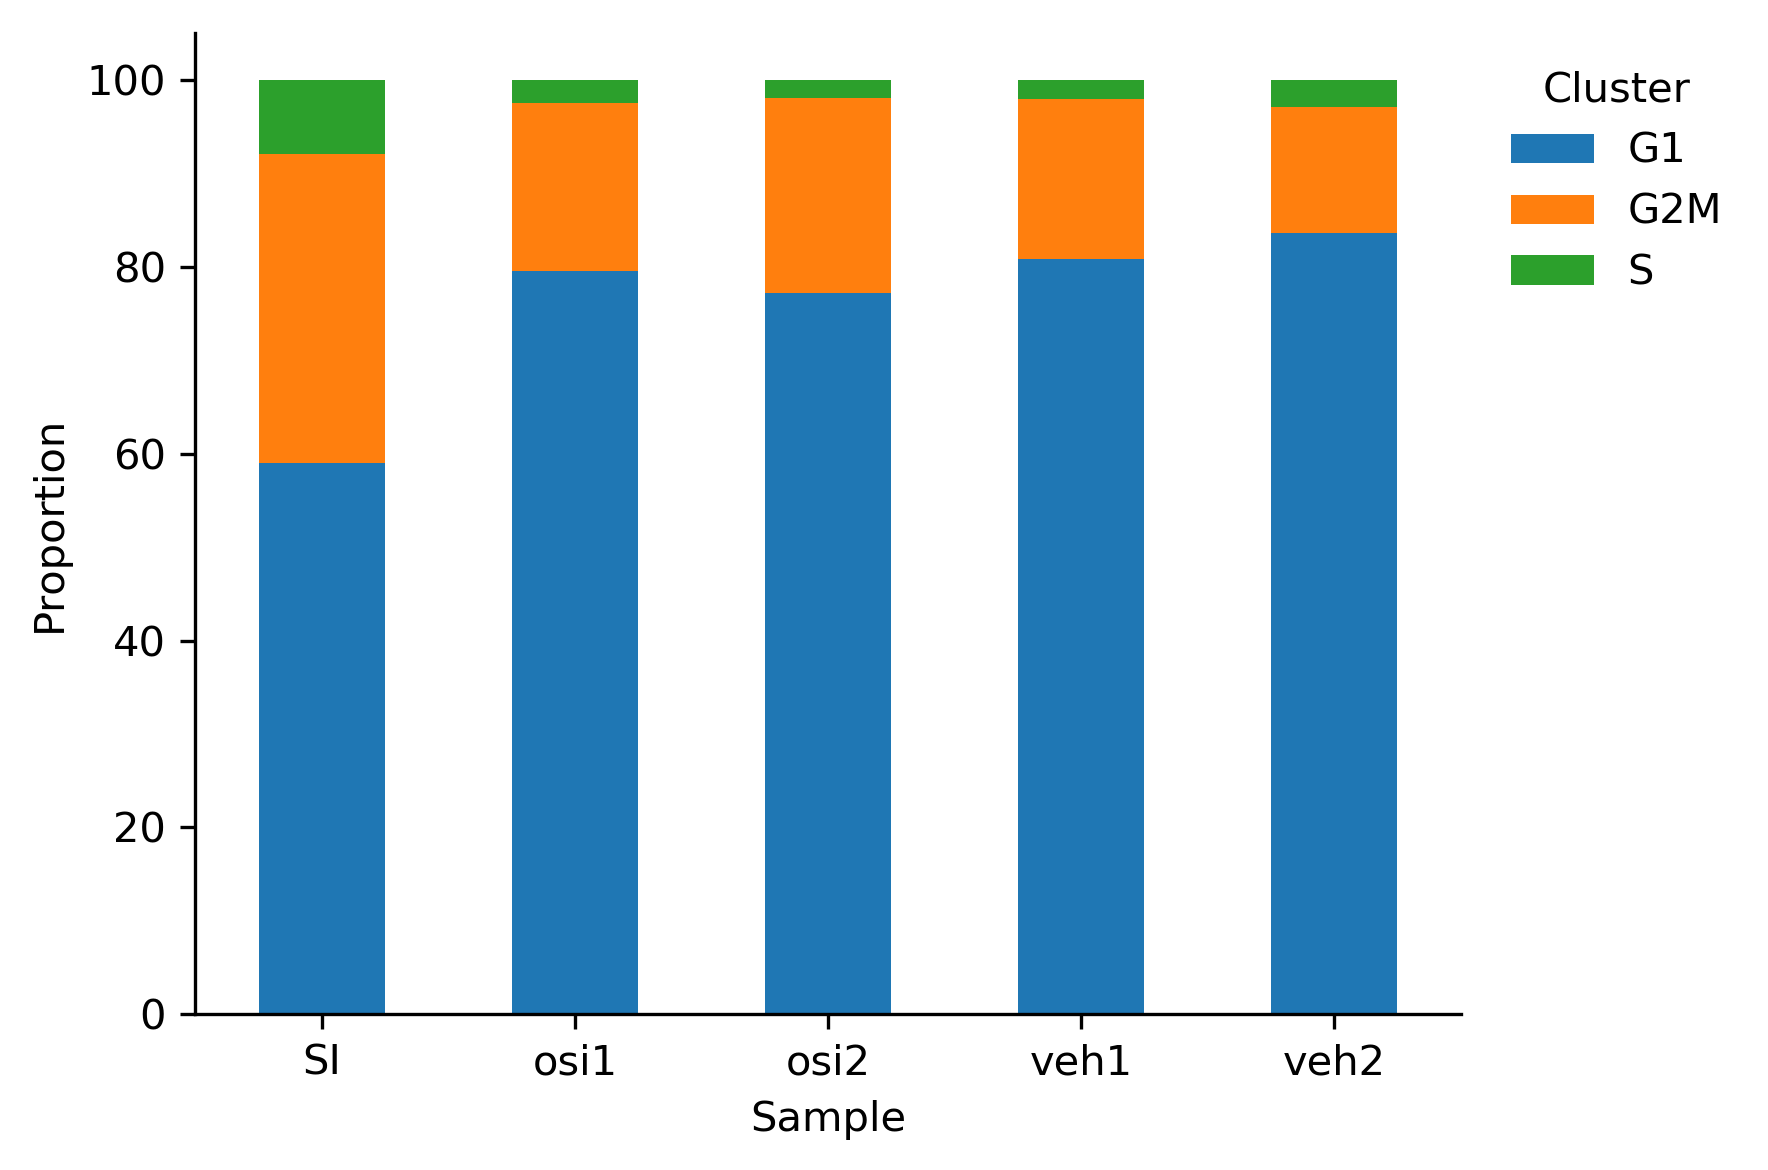

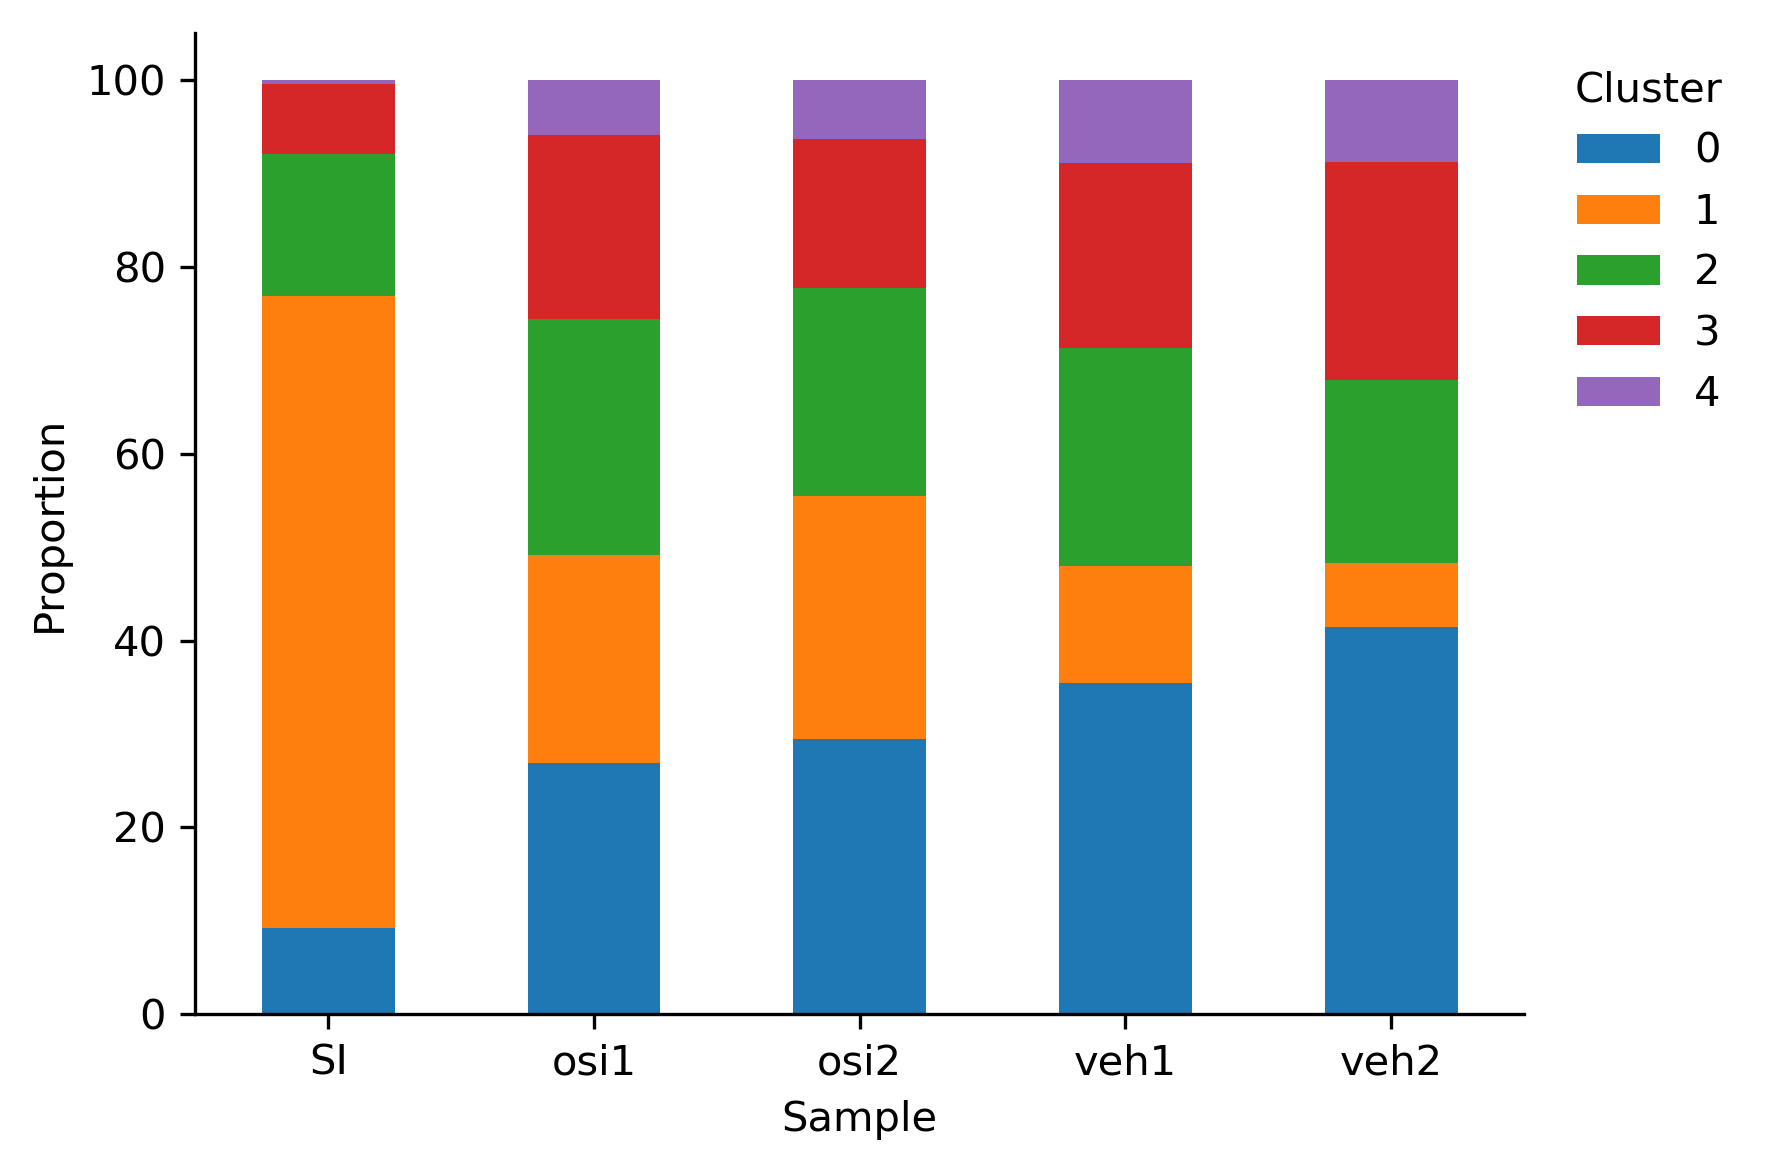

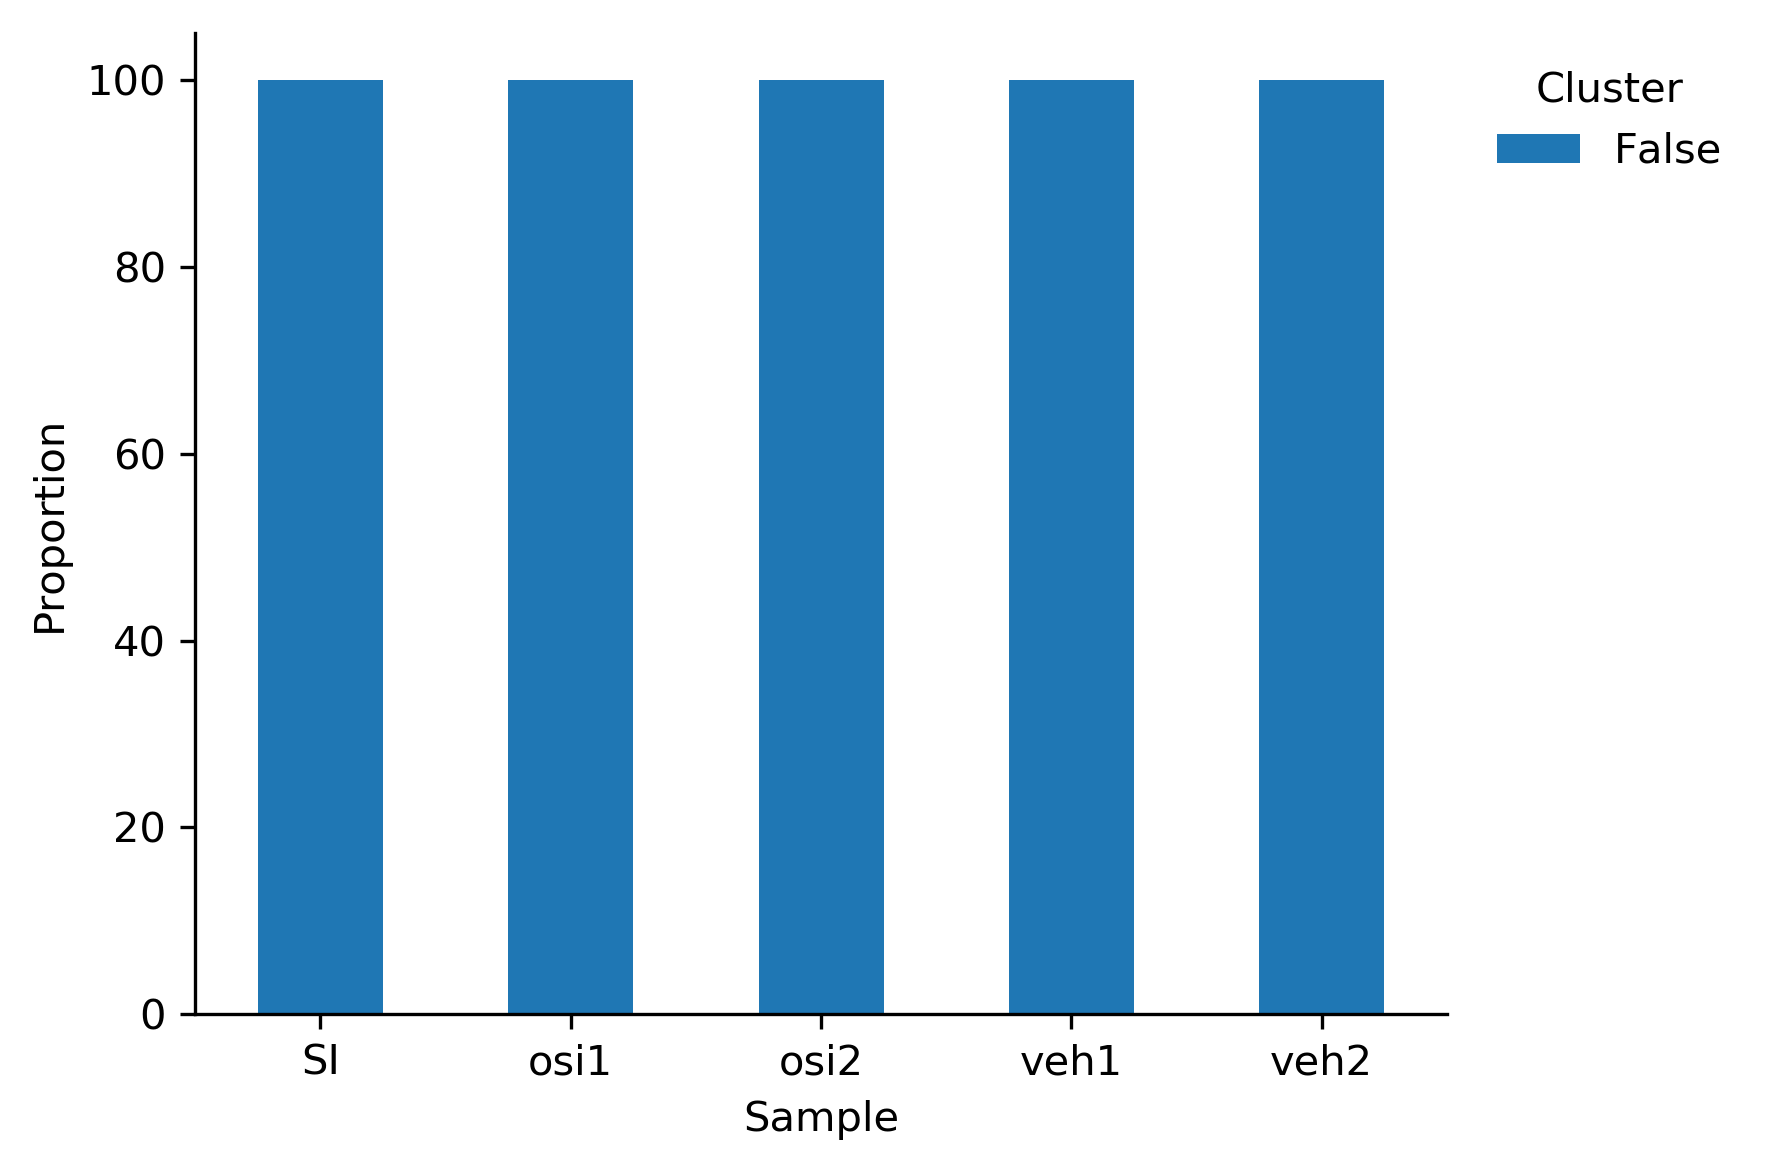

In [8]:
###get clusterplots
clusterplot.plot(clean)

# visualize density by sample
#### A density map is useful when cells are spread out on top of each other.
#### Just specify the key that you want to visualize in this format.

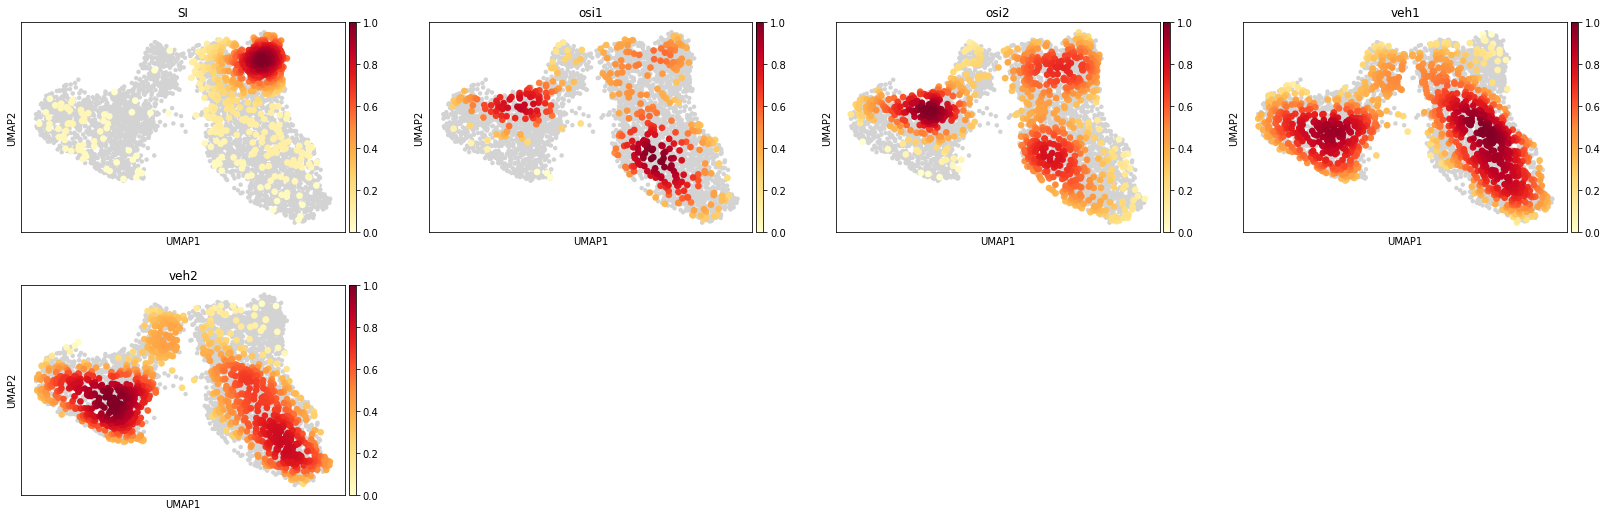

In [9]:
###default key is sample
sceasy.densitymap(clean)

# save data
#### to save or read data just specify the object and the filename

In [10]:
sceasy.save(clean,'mytestfile')